# Week 4 lab: "pandas"
### Data Science for Biology
**Notebook developed by:** *Kinsey Long*<br>

### Learning Outcomes

In this notebook, you will practice:
* Examining DataFrames
* Indexing DataFrames
* Manipulating DataFrames

---
### Helpful Data Science Resources
Here are some resources you can check out while doing this notebook!

- [Data 8 Python Reference](https://www.data8.org/fa23/reference/)
- [DS4BIO Pandas Guide](pandas_guide.ipynb)
- Recommended activity: Map each Data 8 method to its corresponding Pandas method.
- [Data 100 Pandas Reference](https://ds100.org/su22/resources/assets/exams/su22/su22_final_reference_sheet.pdf)
- [Introductory documentation for pandas](https://pandas.pydata.org/docs/user_guide/10min.html)

### AI Policy Reminder

In the course, the default is that AI tools (such as ChatGPT, Gemini, Claude, Copilot, and Grok) may not be used in any way, unless specifically authorized. 

However, unless otherwise noted, for this class you may use AI tools for writing executable code in the class laboratory notebook assignments.  Note, certain labs do not permit use of AI.  To reiterate, you may not use such tools for free-text answers, written explanations, conceptual or similar questions on laboratory notebooks, in any way for presentations, or for other class activities unless explicitly approved.

Whenever AI tools are permitted, you must document their use.

Note that when AI is permitted, you may only share any course content with an AI tool that complies with the Course material integrity policy (as below).  Unless you have received explicit permission, you may only use tools that have been certified by the campus. At the time of writing, the tools licensed by the campus for students that comply with the course material integrity requirement are Google Gemini, Google NotebookLM, BearGPT, and probably Copilot -- and these only meet the requirements when used under the University License (e.g., logged in with your Berkeley ID).  In general, tools safe for P3 data are suitable for class use.

---

Until this point, our journey through data manipulation has been guided by a custom library designed specifically for Data 8. The techniques we've learned in Data 8 serve as a foundation for what lies ahead—a transition to the versatile world of Pandas. Think of Pandas as the next level of our data manipulation adventure. While all the table methods familiarized in Data 8 seamlessly translate into Pandas, it's important to note that working with Pandas often introduces additional intricacies and considerations. This powerful Python library takes center stage in the realm of data wrangling and exploration, due to its distinctive table-like data type known as a DataFrame.

### 1. Examining DataFrames

First, we need to import the pandas library. It's most well-known abbreviated name is `pd`, which is what we will rename the library as.

In [1]:
#Just run this cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In this lab, we will be working with data from the Clinical Proteomic Tumor Analysis Consortium (NCI/NIH). In this particular experiment, breast cancer samples were taken from 77 patients. The researchers performed iTRAQ proteome profiling, a mass spectrometry technique for measuring relative protein abundance across a set of samples. Expression values for ~12,000 proteins for each sample in the dataset can be found in the extra file `cancer_proteomics.csv`.

For the bulk of this lab, we will be working with the clinical profiles for each of the participants, stored in the dataset `clinical_data.csv`. The proteomics data itself will be used in the extra credit problems.

<font color = #d14d0f>**QUESTION 1a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Import the `'clinical_data.csv'` into the DataFrame `clinical_data`.

In [2]:
# YOUR CODE HERE
clinical_data = pd.read_csv('clinical_data.csv')

In [3]:
# QUICK CHECK
clinical_data.shape

(77, 13)

<font color = #d14d0f>**QUESTION 1b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Display the first 5 rows of `clinical_data`.

In [4]:
# YOUR CODE HERE
clinical_data.head()

,Complete TCGA ID,Gender,Age at Initial Pathologic Diagnosis,ER Status,PR Status,HER2 Final Status,Tumor,Node,Node-Coded,Metastasis,AJCC Stage,Vital Status,Days to date of Death
0,TCGA-A2-A0CM,FEMALE,40,Negative,Negative,Negative,T2,N0,Negative,M0,Stage IIA,DECEASED,754.0
1,TCGA-BH-A18Q,FEMALE,56,Negative,Negative,Negative,T2,N1,Positive,M0,Stage IIB,DECEASED,1692.0
2,TCGA-A7-A0CE,FEMALE,57,Negative,Negative,Negative,T2,N0,Negative,M0,Stage IIA,LIVING,NaN
3,TCGA-D8-A142,FEMALE,74,Negative,Negative,Negative,T3,N0,Negative,M0,Stage IIB,LIVING,NaN
4,TCGA-AO-A0J6,FEMALE,61,Negative,Negative,Negative,T2,N0,Negative,M0,Stage IIA,LIVING,NaN


Lets take a moment to understand what this dataframe is.

- Complete TCGA ID: Unique identification code for each patient.
- Gender: The patient's biological sex.
- Age at Initial Pathologic Diagnosis: How old the patient was when cancer was first found.
- ER Status: Shows if estrogen helps the cancer grow.
- PR Status: Shows if progesterone helps the cancer grow.
- HER2 Final Status: A protein test; "Positive" usually means a more aggressive cancer.
- Tumor: The size and reach of the original tumor (T1–T4).
- Node: How many nearby lymph nodes have cancer (N0–N3).
- Node-Coded: A simple "Positive" or "Negative" for lymph node spread.
- Metastasis: Whether the cancer has spread to distant parts of the body (M0 or M1).
- AJCC Stage: The overall severity of the cancer (Stage I to Stage IV).
- Vital Status: Whether the patient is living or deceased.
- Days to date of Death: How many days the patient lived after diagnosis (if deceased).

Throughout the lab you will receive more information on each column.

<font color = #d14d0f>**QUESTION 1c**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

How many patients are in `clinical_data`? Assign the value to `num_patients`. Do not hard-code this value.

In [5]:
# YOUR CODE HERE
num_patients = num_patients = len(clinical_data)

print(f"There are {num_patients} patients in our DataFrame.")

There are 77 patients in our DataFrame.


### 2. Indexing DataFrames

<font color = #d14d0f>**QUESTION 2**:</font> <font color = #0fd12c>**NO AI**</font>

What is the difference between a pandas `Series` and `DataFrame`? What are some similarities? It may be helpful to refer to the documentation and resources we provided at the beginning of this lab.

**ANSWER:** Series are one dimensional while DataFrames are two dimensional. Both can read numbers, although series can process other kinds of data as well. 

<font color = #d14d0f>**QUESTION 3a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Assign `diagnosis_age` to a pandas `Series` containing each patient's Age at Initial Pathologic Diagnosis.

In [6]:
# YOUR CODE HERE
diagnosis_age = clinical_data['Age at Initial Pathologic Diagnosis']

In [7]:
# QUICK CHECK
isinstance(diagnosis_age, pd.Series)

True

<font color = #d14d0f>**QUESTION 3b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Use indexing methods to assign `youngest_patient_diagnosis_age` to the youngest age at diagnosis in `clinical_data`.

In [8]:
# YOUR CODE HERE
youngest_patient_diagnosis_age = youngest_patient_diagnosis_age = diagnosis_age.min()

print(f"The youngest patient at diagnosis is {youngest_patient_diagnosis_age}.")

The youngest patient at diagnosis is 30.


In [9]:
# QUICK CHECK
youngest_patient_diagnosis_age in range(20, 40)

True

Pandas has built-in plotting capabilities that leverage `matplotlib.pyplot` to easily generate figures.

<font color = #d14d0f>**QUESTION 4**:</font>  <font color = #0fd12c>**AI PERMITTED**</font>

Plot and display a histogram showing the distribution of patient ages, using the built-in `pandas` plotting functionality. Add appropriate labels and a title. Do not import any additional packages.

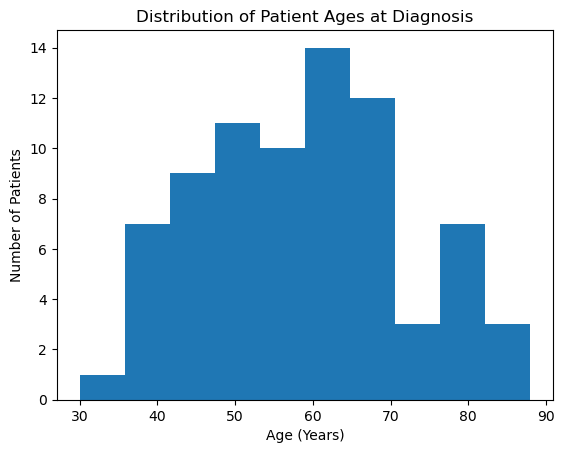

In [10]:
# YOUR CODE HERE
diagnosis_age.plot(kind='hist', title='Distribution of Patient Ages at Diagnosis')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Patients')

# Show the plot
plt.show()

<font color = #d14d0f>**QUESTION 5**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

What is the AJCC stage of the patient at row index 50? Assign the string result to `q5_answer`. Again, do not hard-code the answer.

In [11]:
# YOUR CODE HERE
q5_answer = clinical_data.loc[50, 'AJCC Stage']

print(f"The AJCC stage of the patient at row index 50 is {q5_answer}.")

The AJCC stage of the patient at row index 50 is Stage IIA.


<font color = #d14d0f>**QUESTION 6**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a new DataFrame `selected_columns` with only the columns `'Gender'`, `'Age at Initial Pathologic Diagnosis'` and `'AJCC Stage'`.

In [12]:
# YOUR CODE HERE
selected_columns = clinical_data[['Gender', 'Age at Initial Pathologic Diagnosis', 'AJCC Stage']]

Here's some more information on [AJCC Stages](https://www.cancer.gov/about-cancer/diagnosis-staging/staging).

In [13]:
# QUICK CHECK
selected_columns.columns.tolist()

['Gender', 'Age at Initial Pathologic Diagnosis', 'AJCC Stage']

<font color = #d14d0f>**QUESTION 7a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a Series containing the number of individuals at each AJCC Stage.

> Hint: check out pandas `value_counts`.

In [14]:
# YOUR CODE HERE
grouped_AJCC_stage_series = clinical_data['AJCC Stage'].value_counts()

grouped_AJCC_stage_series

Stage IIA     22
Stage IIB     18
Stage II       9
Stage IIIA     7
Stage IIIB     5
Stage IA       4
Stage IIIC     4
Stage I        3
Stage III      3
Stage IV       1
Stage IB       1
Name: AJCC Stage, dtype: int64

In [15]:
# QUICK CHECK
isinstance(grouped_AJCC_stage_series, pd.Series)

True

<font color = #d14d0f>**QUESTION 7b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Which AJCC Stage has the most number of patients? Assign your string answer to `most_patients_AJCC_stage`. Do not hard-code.
> Hint: check out pandas `idxmax`. How is it different from `max`?

In [16]:
# YOUR CODE HERE
most_patients_AJCC_stage = most_patients_AJCC_stage = grouped_AJCC_stage_series.idxmax()

print(most_patients_AJCC_stage)

Stage IIA


In [17]:
# QUICK CHECK
isinstance(most_patients_AJCC_stage, str)

True

### 3. Filtering and Manipulating DataFrames

<font color = #d14d0f>**QUESTION 8**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

How many patients are at the AJCC Stage of 'Stage IIA'? Assign the value to `num_stage_2a`. As always, please do not hard-code the value.

In [18]:
# YOUR CODE HERE
num_stage_2a = int(grouped_AJCC_stage_series['Stage IIA'])

print(f"There are {num_stage_2a} patients at Stage IIA.")

There are 22 patients at Stage IIA.


In [19]:
# QUICK CHECK
isinstance(num_stage_2a, int) or isinstance(num_stage_2a, float)

True

<font color = #d14d0f>**QUESTION 9a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Assign the row corresponding to the youngest patient with a T2 type tumor to the variable `youngest_t2` as a Series. Hint: it may be helpful to use pandas's `iloc`.

In [20]:
# YOUR CODE HERE
t2_only = clinical_data[clinical_data['Tumor'] == 'T2']
youngest_t2 = t2_only.sort_values('Age at Initial Pathologic Diagnosis').iloc[0]

youngest_t2

Complete TCGA ID                       TCGA-BH-A0DG
Gender                                       FEMALE
Age at Initial Pathologic Diagnosis              30
ER Status                                  Positive
PR Status                                  Negative
HER2 Final Status                          Negative
Tumor                                            T2
Node                                             N0
Node-Coded                                 Negative
Metastasis                                       M0
AJCC Stage                                Stage IIA
Vital Status                                 LIVING
Days to date of Death                           NaN
Name: 50, dtype: object

In [21]:
# QUICK CHECK
isinstance(youngest_t2, pd.Series)

True

In [22]:
# QUICK CHECK
len(youngest_t2) == 13

True

<font color = #d14d0f>**QUESTION 9b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

What is the Complete TCGA ID for the youngest patient with a T2 type tumor? Assign your answer to `youngest_t2_tcga_id`.

In [23]:
# YOUR CODE HERE
youngest_t2_tcga_id = youngest_t2_tcga_id = youngest_t2['Complete TCGA ID']

print(f"The TCGA ID for the youngest patient with T2 type tumor is {youngest_t2_tcga_id}.")

The TCGA ID for the youngest patient with T2 type tumor is TCGA-BH-A0DG.


In [24]:
# QUICK CHECK
isinstance(youngest_t2_tcga_id, str)

True

<font color = #d14d0f>**QUESTION 10**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

How many patients have a T3	tumor and N0 node? Assign your answer to `num_t3_n0`. Hint: think about how you can utilize Python's operators.

In [25]:
# YOUR CODE HERE
num_t3_n0 = num_t3_n0 = len(clinical_data[(clinical_data['Tumor'] == 'T3') & (clinical_data['Node'] == 'N0')])

print(f"There are {num_t3_n0} patients with a T3 tumor and N0 node.")

There are 7 patients with a T3 tumor and N0 node.


In [26]:
# QUICK CHECK
isinstance(num_t3_n0, int) or isinstance(num_t3_n0, float)

True

<font color = #d14d0f>**QUESTION 11**:</font> <font color = #0fd12c>**NO AI**</font>

What does the node column represent?

**ANSWER:** How many of the neighboring lymph nodes also have cancer, giving us info on the stage of the cancer/disease progression.

### 4. Grouping and Pivoting

Reminder: Idiomatic use of pandas `groupby` follows a three-step pattern:

1. Split the data into groups based on a column's values
2. Apply a function to each group independently
3. Combine the results back into a Series or DataFrame

<font color = #d14d0f>**QUESTION 12**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a grouped DataFrame `grouped_AJCC_stage_age` showing the average age at initial pathologic diagnosis of patients for each AJCC Stage. Adapt the final DataFrame so that it only has two columns: `'AJCC Stage'` and `'Mean Age at Initial Pathologic Diagnosis'`. 
> Hint: Before grouping, ensure `clinical_data` only has the necessary columns.

In [27]:
# YOUR CODE HERE
grouped_AJCC_stage_age = clinical_data[['AJCC Stage', 'Age at Initial Pathologic Diagnosis']].groupby('AJCC Stage').mean()
grouped_AJCC_stage_age = grouped_AJCC_stage_age.rename(columns={'Age at Initial Pathologic Diagnosis': 'Mean Age at Initial Pathologic Diagnosis'})
grouped_AJCC_stage_age

,Mean Age at Initial Pathologic Diagnosis
AJCC Stage,
Stage I,66.666667
Stage IA,58.000000
Stage IB,46.000000
Stage II,60.888889
Stage IIA,55.545455
Stage IIB,58.444444
Stage III,63.000000
Stage IIIA,53.857143
Stage IIIB,68.000000


In [28]:
# QUICK CHECK
grouped_AJCC_stage_age.shape

(11, 1)

In [29]:
# QUICK CHECK
grouped_AJCC_stage_age.columns.to_list()[0] == 'Mean Age at Initial Pathologic Diagnosis'

True

<font color = #d14d0f>**QUESTION 13a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Build a function `proportion_negative` that takes in a Series of strings (either "Positive" or "Negative") and outputs the proportion of "Negative" values in the list. If the input list is empty, it should return 0.
- For example, `proportion_negative(Series["Negative", "Positive"])` should output 0.5.

In [30]:
def proportion_negative(series):
    if len(series) == 0:
        return 0
    
    # Calculate proportion of "Negative" values
    return (series == "Negative").sum() / len(series)

In [31]:
# QUICK CHECK
proportion_negative(pd.Series(["Negative", "Negative", "Positive", "Negative"])) == 0.75

True

<font color = #d14d0f>**QUESTION 13b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a new DataFrame `tumor_category_proportions` that has 5 columns: 
- `'Tumor'`: Tumor category (1 row for each unique category).
- `'ER Negative Proportion'`: Proportion of individuals with that tumor category with a negative ER status.
- `'PR Negative Proportion'`: Proportion of individuals with that tumor category with a negative PR status.
- `'HER2 Negative Proportion'`: Proportion of individuals with that tumor category with a negative HER2 Final status.
- `'Node-Coded Negative Proportion'`: Proportion of individuals with that tumor category with a negative HER2 Final status.

In [32]:
# Group, aggregate using your function, and set 'Tumor' as the index to achieve a (4,4) shape
tumor_category_proportions = clinical_data.groupby('Tumor').agg({
    'ER Status': proportion_negative,
    'PR Status': proportion_negative,
    'HER2 Final Status': proportion_negative,
    'Node-Coded': proportion_negative
})

# Rename columns to the requested names
tumor_category_proportions.columns = [
    'ER Negative Proportion', 'PR Negative Proportion', 
    'HER2 Negative Proportion', 'Node-Coded Negative Proportion'
]

tumor_category_proportions

,ER Negative Proportion,PR Negative Proportion,HER2 Negative Proportion,Node-Coded Negative Proportion
Tumor,,,,
T1,0.400000,0.500000,0.800000,0.600000
T2,0.352941,0.490196,0.725490,0.450980
T3,0.090909,0.181818,0.727273,0.636364
T4,0.200000,0.400000,1.000000,0.600000


In [33]:
# QUICK CHECK
tumor_category_proportions.shape == (4,4)

True

Here's more information about [ER, PR, HER, and Negative/Positive Status](https://www.mayoclinic.org/diseases-conditions/breast-cancer/in-depth/breast-cancer/art-20045654).


<font color = #d14d0f>**QUESTION 14**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Create a pivoted DataFrame `AJCC_Tumor_pivot` showing the mean age of initial pathological diagnosis for each combination of AJCC stages and Tumor classifications (T1, T2, T3, T4). Set "AJCC Stage" for the index values, and "Tumor" for the column values. Hint: check out pandas's `pivot_table`.


In [34]:
# YOUR CODE HERE
AJCC_Tumor_pivot = clinical_data.pivot_table(
    values='Age at Initial Pathologic Diagnosis', 
    index='AJCC Stage', 
    columns='Tumor', 
    aggfunc='mean'
)

AJCC_Tumor_pivot

Tumor,T1,T2,T3,T4
AJCC Stage,,,,
Stage I,66.666667,NaN,NaN,NaN
Stage IA,58.000000,NaN,NaN,NaN
Stage IB,NaN,46.000000,NaN,NaN
Stage II,64.000000,60.500000,NaN,NaN
Stage IIA,43.000000,56.800000,NaN,NaN
Stage IIB,NaN,55.000000,63.857143,NaN
Stage III,NaN,63.000000,NaN,NaN
Stage IIIA,NaN,55.000000,52.333333,NaN
Stage IIIB,NaN,NaN,NaN,68.0


In [35]:
# QUICK CHECK
AJCC_Tumor_pivot.shape == (11,4)

True

### 5. Data Transformation

<font color = #d14d0f>**QUESTION 15a**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Build the function `age_category(age)` that accepts an age and assigns it to a category, either `"< 50"` or `">= 50"`.

In [36]:
# YOUR CODE HERE
def age_category(age):
    if age < 50:
        return "< 50"
    else:
        return ">= 50"

In [37]:
# QUICK CHECK
age_category(10)

'< 50'

In [38]:
# QUICK CHECK
age_category(100)

'>= 50'

<font color = #d14d0f>**QUESTION 15b**:</font> <font color = #0fd12c>**AI PERMITTED**</font>

Apply the `age_category` function to add a new column `"Age Category"` to `clinical_data`, classifying each patient by their Age at Initial Pathologic Diagnosis. 

In [39]:
# YOUR CODE HERE
clinical_data['Age Category'] = clinical_data['Age at Initial Pathologic Diagnosis'].apply(age_category)

In [40]:
# QUICK CHECK
"Age Category" in clinical_data.columns

True

In [41]:
# QUICK CHECK
clinical_data.shape == (77, 14)

True

***
### Congratulations! You have finished the lab! Remember to provide the notebook in .ipynb and PDF formats, as well as a PDF containing any AI chats.
***